In [ ]:
import torchvision.transforms as transforms
import torch.utils.data as data
import torchvision.datasets as datasets
import torch
import os

# Constante
BATCH_SIZE = 32
IMG_SIZE = (256, 256) # Je redimensionne car en moyenne elle font 360x410, 256x256 est le choix le plus optimale
ROOT = '../data/clean/'

# Transformations des images
transform = transforms.Compose([transforms.Resize(IMG_SIZE),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
                                ])

# Application des transformations et chargement des données
train_data = datasets.ImageFolder(root=f'{ROOT}train', transform=transform)
val_data = datasets.ImageFolder(root=f'{ROOT}val', transform=transform)
test_data = datasets.ImageFolder(root=f'{ROOT}test', transform=transform)

# Loaders
train_loader = data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
val_loader = data.DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4)
test_loader = data.DataLoader(test_data, batch_size=32, shuffle=False, num_workers=4)

# Vérification de l'utilisation du GPU 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {device}')

Using device: cuda


In [2]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        #recuperation de la classe parente nn.Module
        super(BaselineCNN, self).__init__()

        
        layers = []
        in_channels = 3 # 3 canaux pour les images RGB
        out_channels = 16 #je commence avec 16 filtres pour la convolutions

        for _ in range(5): #5 couches pour arrivés a une taille d'images de 8x8
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2, 2))
            in_channels = out_channels
            out_channels *= 2
        self.features= nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear((out_channels//2)*8*8, 256), # 256 filtres et une taille d'image de 8x8
            nn.ReLU(),
            nn.Linear(256, 2) # 2 classes (dog et cat)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [3]:
#creation des variables pour la boucle d'entrainement

model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss() #fonction de perte pour les problèmes de classification multi-classes
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 100

# variable pour early stopping
best_val_loss = float('inf')
patience = 5
patience_counter = 0

#variable pour visualiation des courbes
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


In [ ]:
# Boucle d'entrainement
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #remettre les gradients à 0

        outputs = model(images) #prediction

        loss = criterion(outputs, labels) #calcul de la perte

        loss.backward()#calcul des gradients

        optimizer.step()#mise a jour des poids

        train_loss += loss.item() #on ajoute l'erreur de ce batch à la perte totale de l'epoch
        _, predicted = torch.max(outputs.data, 1) #prediction de la classe (chat = 0, chien = 1)
        total_train += labels.size(0) #nombre total d'images traitées
        train_correct += (predicted == labels).sum().item() #nombre d'images correctement classées




    train_loss = train_loss / len(train_loader) #on divise la perte totale par le nombre de batchs pour obtenir la perte moyenne par batch
    train_accuracy = train_correct / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): #on désactive le calcul des gradients pour la validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), f'best_model_epoch_{epoch+1}.pth') # Sauvegarde du meilleur modèle
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

Epoch [1/100], Train Loss: 0.5881, Train Acc: 0.6753, Val Loss: 0.4899, Val Acc: 0.7690
Epoch [2/100], Train Loss: 0.4187, Train Acc: 0.8070, Val Loss: 0.3890, Val Acc: 0.8191
Epoch [3/100], Train Loss: 0.3288, Train Acc: 0.8560, Val Loss: 0.3595, Val Acc: 0.8431
Epoch [4/100], Train Loss: 0.2657, Train Acc: 0.8858, Val Loss: 0.3450, Val Acc: 0.8487
Epoch [5/100], Train Loss: 0.2104, Train Acc: 0.9113, Val Loss: 0.3521, Val Acc: 0.8495
Epoch [6/100], Train Loss: 0.1618, Train Acc: 0.9341, Val Loss: 0.3615, Val Acc: 0.8651
Epoch [7/100], Train Loss: 0.1154, Train Acc: 0.9548, Val Loss: 0.3309, Val Acc: 0.8867
Epoch [8/100], Train Loss: 0.0785, Train Acc: 0.9697, Val Loss: 0.4158, Val Acc: 0.8751
Epoch [9/100], Train Loss: 0.0677, Train Acc: 0.9757, Val Loss: 0.4796, Val Acc: 0.8751
Epoch [10/100], Train Loss: 0.0440, Train Acc: 0.9840, Val Loss: 0.6365, Val Acc: 0.8627
Epoch [11/100], Train Loss: 0.0351, Train Acc: 0.9882, Val Loss: 0.6540, Val Acc: 0.8663
Epoch [12/100], Train Loss: 0.

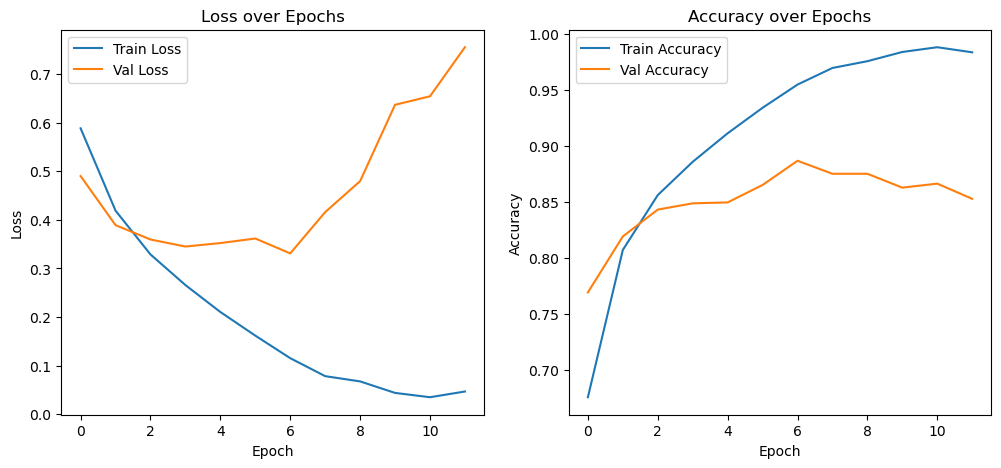

In [5]:
import matplotlib.pyplot as plt

# Tracer les courbes de perte et d'exactitude
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Résultat 

On remarque que le meilleur modèle (ici celui de l'epoch 7 (le 6 dans le graphique)), à seulement 88.67% de prédiction correcte et 33.09% de prédiction fausse sur les données d'évaluation.

Pour améliorer le modèle nous allons faire quelque modification :
* Data Augmentation : Pour que le modèle voie plus de variétés d'images.
* Dropout : Pour forcer le réseau à ne pas dépendre de quelques neurones spécifiques.
* Batch Normalization : Pour accélérer et stabiliser la convergence.

Suite dans 03_optimization_cnn.ipynb
